# ReAct Agents in LangGraph

**ReAct** (*Reason + Act*) is an agent pattern where the LLM alternates between **reasoning** about a task and **acting** by calling tools, then uses each tool's result to decide what to do next. The loop continues until the model has enough information to give a final answer.

## The ReAct loop

1. **Reason**: the LLM reads the conversation and decides whether it needs a tool.
2. **Act**: if it does, it returns a *tool call* (tool name + arguments) instead of a final answer.
3. **Observe**: the tool runs and its output is added back to the conversation as a `ToolMessage`.
4. **Repeat**: the LLM reasons again with the new information, until it answers without calling a tool.

## How this maps to a LangGraph graph

| ReAct step | LangGraph piece |
|---|---|
| Conversation memory | `State` with `messages: Annotated[list, add_messages]` |
| Reason | an LLM node using `llm.bind_tools(tools)` so the model knows which tools exist |
| Act / Observe | `ToolNode(tools)`, a prebuilt node that runs the requested tools and returns `ToolMessage`s |
| Decide: tool or finish? | `tools_condition`, a prebuilt conditional edge that routes to `"tools"` if the last message has tool calls, otherwise to `END` |
| Repeat | an edge from `tools` back to the LLM node |

```
START ──▶ llm ──(tool calls?)──▶ tools
           ▲         │                │
           │         └── no ──▶ END   │
           └──────────────────────────┘
```

## Difference from the basic chatbot (notebook 01)

The chatbot in `01_Basic_AI_ChatBot` was a straight line: `START → chatbot → END`. It could only answer from what the model already knows. A ReAct agent adds **tools** and a **loop**, so it can look things up, calculate, or call APIs, and chain several tool calls before answering.

## Building one

- **By hand:** `StateGraph` + LLM node + `ToolNode` + `tools_condition`. This makes every step visible and is the approach used in this notebook.
- **Prebuilt:** `langchain.agents.create_agent(model, tools=...)` builds the same loop in one call (this replaces the older `langgraph.prebuilt.create_react_agent`).


In [1]:
import os
from dotenv import load_dotenv

# Change working directory to the parent folder
os.chdir(os.path.abspath(".."))
load_dotenv()

True

In [2]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=3)
tool.invoke("What is quantum computing")

{'query': 'What is quantum computing',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/quantum-computing',
   'title': 'What is Quantum Computing?',
   'content': 'Quantum computing is a multidisciplinary field comprising aspects of computer science, physics, and mathematics that utilizes quantum mechanics to solve complex problems faster than on classical computers. The field of quantum computing includes hardware research and application development. Quantum computers are able to solve certain types of problems faster than classical computers by taking advantage of quantum mechanical effects, such as superposition and quantum interference. Some [...] Machine learning (ML) is the process of analyzing vast quantities of data to help computers make better predictions and decisions. Research in quantum computing studies the physical limits of information processing and is breaking new ground in fundamental physics. This r

In [16]:
## define custom function

def multiply(a:int, b:int)-> int:
    """Multiply a and b. Always use this tool for any multiplication
    
    Args: 
    a (int) First value
    b (int) Second value
    
    Returns:
    int: Output int
    """

    return a*b



In [17]:
from langchain_openai import ChatOpenAI

llm =ChatOpenAI(model="gpt-5.1")
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-5.1', 'release_date': '2025-11-13', 'last_updated': '2025-11-13', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['none', 'low', 'medium', 'high']}, client=<openai.resources.chat.completions.completions.Completions object at 0x113b6c190>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x113b6c550>, root_client=

In [18]:
tools=[tool,multiply]
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-5.1', 'release_date': '2025-11-13', 'last_updated': '2025-11-13', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['none', 'low', 'medium', 'high']}, client=<openai.resources.chat.completions.completions.Completions object at 0x113b6c190>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x

In [19]:
## State graph 
from typing import Annotated # context specific metadata 

from typing_extensions import TypedDict

from langgraph.graph.message import add_messages

from langgraph.graph import  StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

print("Import Successfull")

Import Successfull


In [20]:
## State and node definition

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    """Graph state: the conversation, with new messages appended by `add_messages`."""
    messages: Annotated[list, add_messages]


def tool_calling_llm(state: State):
    """Call the tool-aware LLM; its reply may contain tool calls."""
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

In [21]:
## Graph

builder= StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is not a tool call -> tool_condition to END
    tools_condition
)
builder.add_edge("tools",END)

#3compile the graph
graph = builder.compile()


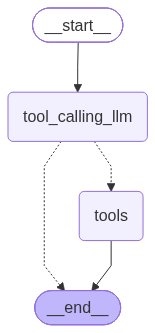

In [22]:
## Visualize graph

from IPython.display import Image,  display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f" Error creating graph image : {e}")

In [23]:
response=graph.invoke({"messages":"What is recent ai news"})
response

{'messages': [HumanMessage(content='What is recent ai news', additional_kwargs={}, response_metadata={}, id='266bcb77-8a9a-4691-80e3-3caf07d242fe'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 1303, 'total_tokens': 1344, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1024, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-ES0kSKsEy34meMMGHJ4kXIjgzIM3M', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0d8dd-2ac2-7c40-9896-b04150071092-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search_depth': 'fast', 'topic': 'news',

In [24]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cyberscoop.com/radio/why-the-recent-sandbox-escapes-didnt-happen-during-safety-testing-but-during-cybersecurity-capability-evals-with-the-guardrails-off/", "title": "Jailbreaks, sandboxes, and the limits of AI safeguards - CyberScoop", "score": 1.0, "published_date": "Thu, 24 Sep 2026 18:07:05 GMT", "content": "Get our latest cybersecurity news first on Google. # Jailbreaks, sandboxes, and the limits of AI safeguards. Matt Fredrikson, associate professor at Carnegie Mellon and CEO and co-founder of Gray Swan AI, built the world’s largest AI red teaming arena, with more than 15,000 people breaking AI systems for prize money. He walks us through how the attacks actually work, from jailbreaks found on small open weights models that transferred straight to frontier systems, to training AI attackers with reinforcement learning. Matt also explains why the recent sandbox escape

In [25]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_7cI0H79ZigJV3wFsPgKZW5ZC)
 Call ID: call_7cI0H79ZigJV3wFsPgKZW5ZC
  Args:
    query: recent AI news
    search_depth: fast
    topic: news
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cyberscoop.com/radio/why-the-recent-sandbox-escapes-didnt-happen-during-safety-testing-but-during-cybersecurity-capability-evals-with-the-guardrails-off/", "title": "Jailbreaks, sandboxes, and the limits of AI safeguards - CyberScoop", "score": 1.0, "published_date": "Thu, 24 Sep 2026 18:07:05 GMT", "content": "Get our latest cybersecurity news first on Google. # Jailbreaks, sandboxes, and the limits

In [26]:
response=graph.invoke({"messages":"What is 2 multiplied by 3"})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_J1xfPlKiUIV5GJfiR5jUntpz)
 Call ID: call_J1xfPlKiUIV5GJfiR5jUntpz
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [27]:
response=graph.invoke({"messages":"What is 2 multiplied by 3 and then multiplied by 10"})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3 and then multiplied by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (call_ZzR1AdujyFJVjiABZIr8rhgp)
 Call ID: call_ZzR1AdujyFJVjiABZIr8rhgp
  Args:
    a: 2
    b: 3
  multiply (call_CNbVGh0jDyM1vS1ZLSiFxack)
 Call ID: call_CNbVGh0jDyM1vS1ZLSiFxack
  Args:
    a: 3
    b: 10
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

30


In [28]:
response=graph.invoke({"messages":"Givem me recent ai news then multiply 5 by 10"})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Givem me recent ai news then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_ugE80lMHSWpr8AjitdVDU1xl)
 Call ID: call_ugE80lMHSWpr8AjitdVDU1xl
  Args:
    query: recent AI news
    search_depth: fast
    topic: news
    time_range: day
  multiply (call_RcIEiEQnGlZu9re2MoWteVJK)
 Call ID: call_RcIEiEQnGlZu9re2MoWteVJK
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cyberscoop.com/radio/why-the-recent-sandbox-escapes-didnt-happen-during-safety-testing-but-during-cybersecurity-capability-evals-with-the-guardrails-off/", "title": "Jailbreaks, sandboxes, and the limits of AI safeguards - CyberScoop", "score": 1.0, "published_date": "T

In [29]:
### React Agent 
## Graph

builder= StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is not a tool call -> tool_condition to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

#3compile the graph
graph = builder.compile()


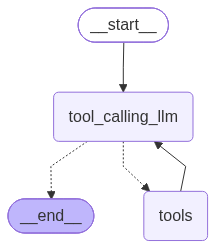

In [30]:
## Visualize graph

from IPython.display import Image,  display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f" Error creating graph image : {e}")

In [31]:
response=graph.invoke({"messages":"Givem me recent ai news then multiply 5 by 10"})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Givem me recent ai news then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_EKRB45eGbzA2dfP3VemUeL8c)
 Call ID: call_EKRB45eGbzA2dfP3VemUeL8c
  Args:
    query: recent AI news
    search_depth: fast
    topic: news
    time_range: day
  multiply (call_Y400616j768kvxsuQnEi8YvI)
 Call ID: call_Y400616j768kvxsuQnEi8YvI
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cyberscoop.com/radio/why-the-recent-sandbox-escapes-didnt-happen-during-safety-testing-but-during-cybersecurity-capability-evals-with-the-guardrails-off/", "title": "Jailbreaks, sandboxes, and the limits of AI safeguards - CyberScoop", "score": 1.0, "published_date": "T